# AD vs Control EEG Classification (Notebook)

This notebook classifies Alzheimer's disease (`A`) vs healthy controls (`C`) from EEG and focuses on:
- **Reliability**: nested CV, bootstrap confidence intervals, permutation significance test
- **Interpretability**: top features, band-channel heatmap, channel-importance topomap

All outputs are displayed inline (no required artifact files).

In [1]:
import os
from pathlib import Path
import warnings

import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import sem, t
from mne.channels.layout import _find_topomap_coords

from sklearn.base import clone
from sklearn.calibration import calibration_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    PrecisionRecallDisplay,
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    classification_report,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.svm import SVC

warnings.filterwarnings('ignore', category=FutureWarning, module='sklearn')
mne.set_log_level('ERROR')

DATA_ROOT = Path.cwd()
PARTICIPANTS_TSV = DATA_ROOT / 'participants.tsv'
GROUP_AD = 'A'
GROUP_CTRL = 'C'
BANDS = {
    'theta': (4.0, 8.0),
    'alpha': (8.0, 13.0),
    'beta': (13.0, 30.0),
    'gamma': (30.0, 45.0),
}
PSD_FMIN = 4.0
PSD_FMAX = 45.0
N_FFT = 2048
RANDOM_STATE = 42
N_JOBS = 1

# Runtime profile
# 'fast' for iteration, 'full' for final reporting
RUNTIME_PROFILE = 'full'

if RUNTIME_PROFILE == 'fast':
    OUTER_FOLDS = 3
    INNER_FOLDS = 2
    N_BOOTSTRAP = 500
    N_PERMUTATIONS = 200
    MODELS_TO_USE = ['logreg_select']
else:
    OUTER_FOLDS = 5
    INNER_FOLDS = 3
    N_BOOTSTRAP = 2000
    N_PERMUTATIONS = 1000
    MODELS_TO_USE = ['logreg_select']

os.environ.setdefault('MPLCONFIGDIR', str(DATA_ROOT / '.mplconfig'))
os.environ.setdefault('XDG_CACHE_HOME', str(DATA_ROOT / '.cache'))
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)
Path(os.environ['XDG_CACHE_HOME']).mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'font.family': 'DejaVu Sans',
    'font.size': 10,
})

# Optional gradient boosting libraries
try:
    from xgboost import XGBClassifier
except Exception:
    XGBClassifier = None

try:
    from lightgbm import LGBMClassifier
except Exception:
    LGBMClassifier = None


In [2]:
def load_subject_table():
    participants = pd.read_csv(PARTICIPANTS_TSV, sep='	')
    participants = participants[['participant_id', 'Group', 'Age']].dropna()
    participants['set_path'] = participants['participant_id'].apply(
        lambda sid: DATA_ROOT / sid / 'eeg' / f'{sid}_task-eyesclosed_eeg.set'
    )
    participants = participants[participants['set_path'].apply(Path.exists)].reset_index(drop=True)
    participants = participants[participants['Group'].isin([GROUP_AD, GROUP_CTRL])].copy()
    return participants


def compute_subject_features(set_path):
    raw = mne.io.read_raw_eeglab(set_path, preload=True, verbose='ERROR')
    raw.pick('eeg')
    raw.set_montage('standard_1020', on_missing='ignore')

    spectrum = raw.compute_psd(method='welch', fmin=PSD_FMIN, fmax=PSD_FMAX, n_fft=N_FFT, verbose='ERROR')
    psd, freqs = spectrum.get_data(return_freqs=True)

    band_power = {}
    for band, (f_lo, f_hi) in BANDS.items():
        band_idx = (freqs >= f_lo) & (freqs < f_hi)
        band_power[band] = np.log10(psd[:, band_idx] + 1e-20).mean(axis=1)
    return raw.ch_names, band_power


def collect_dataset(participants):
    records = []
    common_channels = None

    for row in participants.itertuples(index=False):
        ch_names, band_power = compute_subject_features(row.set_path)
        common_channels = set(ch_names) if common_channels is None else common_channels & set(ch_names)
        records.append({'id': row.participant_id, 'group': row.Group, 'age': float(row.Age), 'ch_names': ch_names, 'band_power': band_power})

    first_order = records[0]['ch_names']
    common_ordered = [ch for ch in first_order if ch in common_channels]

    feature_names = []
    for band in BANDS:
        for ch in common_ordered:
            feature_names.append(f'logpow_{band}_{ch}')
    for band in BANDS:
        for ch in common_ordered:
            feature_names.append(f'relpow_{band}_{ch}')

    X_rows, y_rows, meta_rows = [], [], []
    for rec in records:
        idx = [rec['ch_names'].index(ch) for ch in common_ordered]
        band_mat = np.vstack([rec['band_power'][band][idx] for band in BANDS])
        pow_lin = 10.0 ** band_mat
        rel = pow_lin / (pow_lin.sum(axis=0, keepdims=True) + 1e-20)
        feat = np.concatenate([band_mat.ravel(order='C'), rel.ravel(order='C'), np.array([rec['age']], dtype=float)])

        X_rows.append(feat)
        y_rows.append(1 if rec['group'] == GROUP_AD else 0)
        meta_rows.append({'participant_id': rec['id'], 'Group': rec['group'], 'Age': rec['age']})

    X = np.vstack(X_rows)
    y = np.array(y_rows, dtype=int)
    meta_df = pd.DataFrame(meta_rows)
    feature_names = feature_names + ['age_years']
    return X, y, feature_names, meta_df, common_ordered


participants = load_subject_table()
print('Group counts:', participants['Group'].value_counts())

X, y, feature_names, meta_df, common_channels = collect_dataset(participants)
print('Feature matrix:', X.shape)
print('Channels:', common_channels)

Group counts: Group
A    36
C    29
Name: count, dtype: int64
Feature matrix: (65, 153)
Channels: ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T3', 'T4', 'T5', 'T6', 'Fz', 'Cz', 'Pz']


In [3]:
from sklearn.metrics import accuracy_score as _acc

def build_model_grids(models_to_use=None):
    models = {}

    # Strong low-sample baseline: linear model + univariate feature selection
    pipe_lr_sel = Pipeline([
        ('scaler', StandardScaler()),
        ('sel', SelectKBest(f_classif)),
        ('clf', LogisticRegression(solver='liblinear', random_state=RANDOM_STATE, max_iter=5000)),
    ])
    lr_sel_grid = {
        'sel__k': [40, 80, 120] if RUNTIME_PROFILE == 'fast' else [20, 40, 60, 80, 120],
        'clf__C': [0.1, 1.0, 10.0] if RUNTIME_PROFILE == 'fast' else [0.01, 0.1, 1.0, 10.0, 100.0],
        'clf__class_weight': [None, 'balanced'],
    }
    models['logreg_select'] = (pipe_lr_sel, lr_sel_grid)

    pipe_svm_sel = Pipeline([
        ('scaler', StandardScaler()),
        ('sel', SelectKBest(f_classif)),
        ('clf', SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE)),
    ])
    svm_sel_grid = {
        'sel__k': [40, 80, 120] if RUNTIME_PROFILE == 'fast' else [20, 40, 60, 80, 120],
        'clf__C': [0.1, 1.0, 10.0] if RUNTIME_PROFILE == 'fast' else [0.1, 1.0, 10.0, 50.0],
        'clf__gamma': ['scale', 0.01] if RUNTIME_PROFILE == 'fast' else ['scale', 0.1, 0.01, 0.001],
        'clf__class_weight': [None, 'balanced'],
    }
    models['svm_select'] = (pipe_svm_sel, svm_sel_grid)

    if models_to_use is not None:
        models = {k: v for k, v in models.items() if k in models_to_use}
    return models


def ci95(values):
    values = np.asarray(values, dtype=float)
    if len(values) < 2:
        return float(values[0]), float(values[0])
    mean_v = float(np.mean(values))
    delta = float(t.ppf(0.975, df=len(values) - 1) * sem(values))
    return mean_v - delta, mean_v + delta


def _best_train_threshold(y_true, y_prob):
    # Tune operating point for accuracy on training fold (user requested).
    thresholds = np.linspace(0.2, 0.8, 61)
    best_t, best_score = 0.5, -1.0
    for t in thresholds:
        pred = (y_prob >= t).astype(int)
        score = _acc(y_true, pred)
        if score > best_score:
            best_t, best_score = float(t), float(score)
    return best_t


def evaluate_nested_cv(X, y, model_grids, outer_folds=OUTER_FOLDS, inner_folds=INNER_FOLDS):
    outer_cv = StratifiedKFold(n_splits=outer_folds, shuffle=True, random_state=RANDOM_STATE)
    inner_cv = StratifiedKFold(n_splits=inner_folds, shuffle=True, random_state=RANDOM_STATE)
    records = []

    for fold_idx, (tr_idx, te_idx) in enumerate(outer_cv.split(X, y), start=1):
        X_tr, X_te = X[tr_idx], X[te_idx]
        y_tr, y_te = y[tr_idx], y[te_idx]

        best_name, best_score, best_estimator, best_params = None, -np.inf, None, None

        for name, (pipe, grid) in model_grids.items():
            gs = GridSearchCV(clone(pipe), grid, scoring='roc_auc', cv=inner_cv, n_jobs=N_JOBS, refit=True)
            gs.fit(X_tr, y_tr)
            if gs.best_score_ > best_score:
                best_name, best_score = name, gs.best_score_
                best_estimator, best_params = gs.best_estimator_, gs.best_params_

        train_prob = best_estimator.predict_proba(X_tr)[:, 1]
        threshold = _best_train_threshold(y_tr, train_prob)

        prob = best_estimator.predict_proba(X_te)[:, 1]
        pred = (prob >= threshold).astype(int)

        tn = int(np.sum((y_te == 0) & (pred == 0)))
        fp = int(np.sum((y_te == 0) & (pred == 1)))
        fn = int(np.sum((y_te == 1) & (pred == 0)))
        tp = int(np.sum((y_te == 1) & (pred == 1)))

        records.append({
            'fold': fold_idx,
            'te_idx': te_idx.copy(),
            'model': best_name,
            'inner_best_roc_auc': float(best_score),
            'best_params': best_params,
            'threshold': threshold,
            'y_true': y_te,
            'y_prob': prob,
            'y_pred': pred,
            'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp,
            'roc_auc': float(roc_auc_score(y_te, prob)),
            'accuracy': float(accuracy_score(y_te, pred)),
            'balanced_accuracy': float(balanced_accuracy_score(y_te, pred)),
            'f1': float(f1_score(y_te, pred)),
            'sensitivity': float(tp / (tp + fn + 1e-20)),
            'specificity': float(tn / (tn + fp + 1e-20)),
        })
    return records


def summarize_cv(records):
    metrics = ['roc_auc', 'balanced_accuracy', 'accuracy', 'f1', 'sensitivity', 'specificity']
    out = {}
    for m in metrics:
        vals = np.array([r[m] for r in records], dtype=float)
        low, high = ci95(vals)
        out[m] = {'mean': float(np.mean(vals)), 'std': float(np.std(vals, ddof=1)), 'ci95_low': low, 'ci95_high': high}
    out['selected_model_counts'] = pd.Series([r['model'] for r in records]).value_counts().to_dict()
    return out

In [4]:
model_grids = build_model_grids(models_to_use=MODELS_TO_USE)
fold_records = evaluate_nested_cv(X, y, model_grids, outer_folds=OUTER_FOLDS, inner_folds=INNER_FOLDS)
print(f'Runtime profile={RUNTIME_PROFILE}, models={list(model_grids.keys())}, outer={OUTER_FOLDS}, inner={INNER_FOLDS}')
summary = summarize_cv(fold_records)

# Correctly align OOF predictions back to subject index
y_true_oof = np.zeros(len(y), dtype=int)
y_prob_oof = np.zeros(len(y), dtype=float)
y_pred_oof = np.zeros(len(y), dtype=int)
for r in fold_records:
    te_idx = np.array(r['te_idx'], dtype=int)
    y_true_oof[te_idx] = np.array(r['y_true'], dtype=int)
    y_prob_oof[te_idx] = np.array(r['y_prob'], dtype=float)
    y_pred_oof[te_idx] = np.array(r['y_pred'], dtype=int)

fold_df = pd.DataFrame([
    {
        'fold': r['fold'],
        'selected_model': r['model'],
        'inner_best_roc_auc': r['inner_best_roc_auc'],
        'threshold': r['threshold'],
        'roc_auc': r['roc_auc'],
        'balanced_accuracy': r['balanced_accuracy'],
        'accuracy': r['accuracy'],
        'f1': r['f1'],
        'sensitivity': r['sensitivity'],
        'specificity': r['specificity'],
        'tn': r['tn'], 'fp': r['fp'], 'fn': r['fn'], 'tp': r['tp'],
    }
    for r in fold_records
])

display(fold_df)
summary

Runtime profile=full, models=['logreg_select'], outer=5, inner=3


,fold,selected_model,inner_best_roc_auc,threshold,roc_auc,balanced_accuracy,accuracy,f1,sensitivity,specificity,tn,fp,fn,tp
0,1,logreg_select,0.732407,0.45,0.875000,0.800000,0.846154,0.888889,1.000000,0.600000,3,2,0,8
1,2,logreg_select,0.851852,0.35,0.714286,0.750000,0.769231,0.823529,1.000000,0.500000,3,3,0,7
2,3,logreg_select,0.810913,0.52,0.904762,0.773810,0.769231,0.769231,0.714286,0.833333,5,1,2,5
3,4,logreg_select,0.752050,0.32,0.976190,0.916667,0.923077,0.933333,1.000000,0.833333,5,1,0,7
4,5,logreg_select,0.851323,0.44,0.547619,0.630952,0.615385,0.545455,0.428571,0.833333,5,1,4,3


{'roc_auc': {'mean': 0.8035714285714286,
  'std': 0.17220804930344566,
  'ci95_low': 0.5897468935504409,
  'ci95_high': 1.0173959635924164},
 'balanced_accuracy': {'mean': 0.7742857142857142,
  'std': 0.1025524587843758,
  'ci95_low': 0.6469500182858792,
  'ci95_high': 0.9016214102855493},
 'accuracy': {'mean': 0.7846153846153846,
  'std': 0.11409536133993327,
  'ci95_low': 0.6429472820775396,
  'ci95_high': 0.9262834871532296},
 'f1': {'mean': 0.7920873897344486,
  'std': 0.15137679193776848,
  'ci95_low': 0.6041282770217393,
  'ci95_high': 0.9800465024471579},
 'sensitivity': {'mean': 0.8285714285714286,
  'std': 0.25555062599997597,
  'ci95_low': 0.511263416548823,
  'ci95_high': 1.1458794405940342},
 'specificity': {'mean': 0.7200000000000001,
  'std': 0.15916448515084433,
  'ci95_low': 0.5223711889955587,
  'ci95_high': 0.9176288110044415},
 'selected_model_counts': {'logreg_select': 5}}

In [5]:
def bootstrap_metrics(y_true, y_prob, threshold=0.5, n_bootstrap=N_BOOTSTRAP):
    rng = np.random.default_rng(RANDOM_STATE)
    idx_pos = np.where(y_true == 1)[0]
    idx_neg = np.where(y_true == 0)[0]

    boot = {k: [] for k in ['roc_auc','average_precision','balanced_accuracy','accuracy','f1','sensitivity','specificity','brier_score']}

    for _ in range(n_bootstrap):
        sample_pos = rng.choice(idx_pos, size=len(idx_pos), replace=True)
        sample_neg = rng.choice(idx_neg, size=len(idx_neg), replace=True)
        sample_idx = np.concatenate([sample_pos, sample_neg])
        rng.shuffle(sample_idx)

        yt = y_true[sample_idx]
        yp = y_prob[sample_idx]
        yhat = (yp >= threshold).astype(int)

        tn = int(np.sum((yt == 0) & (yhat == 0)))
        fp = int(np.sum((yt == 0) & (yhat == 1)))
        fn = int(np.sum((yt == 1) & (yhat == 0)))
        tp = int(np.sum((yt == 1) & (yhat == 1)))

        boot['roc_auc'].append(roc_auc_score(yt, yp))
        boot['average_precision'].append(average_precision_score(yt, yp))
        boot['balanced_accuracy'].append(balanced_accuracy_score(yt, yhat))
        boot['accuracy'].append(accuracy_score(yt, yhat))
        boot['f1'].append(f1_score(yt, yhat))
        boot['sensitivity'].append(tp / (tp + fn + 1e-20))
        boot['specificity'].append(tn / (tn + fp + 1e-20))
        boot['brier_score'].append(brier_score_loss(yt, yp))

    out = {}
    for metric, vals in boot.items():
        arr = np.array(vals, dtype=float)
        out[metric] = {
            'mean': float(np.mean(arr)),
            'ci95_low': float(np.quantile(arr, 0.025)),
            'ci95_high': float(np.quantile(arr, 0.975)),
        }
    return out


def permutation_auc_test(y_true, y_prob, n_permutations=N_PERMUTATIONS):
    rng = np.random.default_rng(RANDOM_STATE)
    observed = float(roc_auc_score(y_true, y_prob))
    perm_scores = np.zeros(n_permutations, dtype=float)
    for i in range(n_permutations):
        perm_scores[i] = roc_auc_score(rng.permutation(y_true), y_prob)
    p_value = float((np.sum(perm_scores >= observed) + 1) / (len(perm_scores) + 1))
    return {
        'observed_auc': observed,
        'null_mean_auc': float(np.mean(perm_scores)),
        'null_std_auc': float(np.std(perm_scores, ddof=1)),
        'permutation_p_value': p_value,
    }


boot_summary = bootstrap_metrics(y_true_oof, y_prob_oof)
perm_test = permutation_auc_test(y_true_oof, y_prob_oof)

print('Bootstrap ROC-AUC 95% CI:', f"[{boot_summary['roc_auc']['ci95_low']:.3f}, {boot_summary['roc_auc']['ci95_high']:.3f}]")
print('Permutation test p-value (AUC vs shuffled labels):', f"{perm_test['permutation_p_value']:.4g}")

pd.DataFrame(boot_summary).T

Bootstrap ROC-AUC 95% CI: [0.676, 0.907]
Permutation test p-value (AUC vs shuffled labels): 0.000999


,mean,ci95_low,ci95_high
roc_auc,0.800207,0.676245,0.907112
average_precision,0.821030,0.688846,0.930364
balanced_accuracy,0.750214,0.636973,0.847701
accuracy,0.753115,0.646154,0.846154
f1,0.776546,0.675676,0.868421
sensitivity,0.777153,0.638889,0.889583
specificity,0.723276,0.551724,0.862069
brier_score,0.179711,0.114621,0.255534


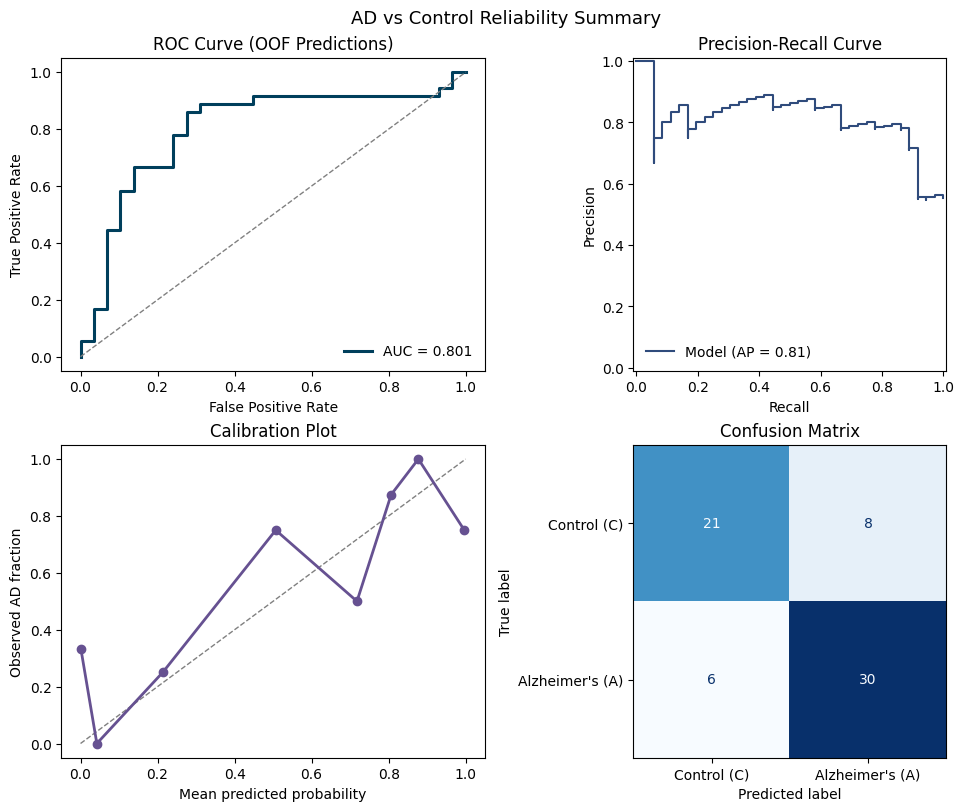

In [6]:
# Reliability plots: ROC, PR, calibration, confusion matrix
fpr, tpr, _ = roc_curve(y_true_oof, y_prob_oof)
roc_auc = roc_auc_score(y_true_oof, y_prob_oof)
pr_auc = average_precision_score(y_true_oof, y_prob_oof)
precision, recall, _ = precision_recall_curve(y_true_oof, y_prob_oof)
frac_pos, mean_pred = calibration_curve(y_true_oof, y_prob_oof, n_bins=8, strategy='quantile')

fig, axes = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)
ax_roc, ax_pr, ax_cal, ax_cm = axes.ravel()

ax_roc.plot(fpr, tpr, lw=2.2, color='#003f5c', label=f'AUC = {roc_auc:.3f}')
ax_roc.plot([0, 1], [0, 1], '--', color='gray', lw=1)
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.set_title('ROC Curve (OOF Predictions)')
ax_roc.legend(loc='lower right', frameon=False)

PrecisionRecallDisplay(precision=precision, recall=recall, average_precision=pr_auc).plot(
    ax=ax_pr, name='Model', color='#2f4b7c'
)
ax_pr.set_title('Precision-Recall Curve')
ax_pr.legend(loc='lower left', frameon=False)

ax_cal.plot([0, 1], [0, 1], '--', color='gray', lw=1)
ax_cal.plot(mean_pred, frac_pos, marker='o', lw=2, color='#665191')
ax_cal.set_xlabel('Mean predicted probability')
ax_cal.set_ylabel('Observed AD fraction')
ax_cal.set_title('Calibration Plot')

ConfusionMatrixDisplay.from_predictions(
    y_true_oof, y_pred_oof,
    display_labels=['Control (C)', "Alzheimer's (A)"],
    cmap='Blues', ax=ax_cm, colorbar=False,
)
ax_cm.set_title('Confusion Matrix')

fig.suptitle('AD vs Control Reliability Summary', fontsize=13)
plt.show()

In [7]:
# Train final model on full dataset for feature-importance interpretation
def train_final_model(X, y, model_grids):
    inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    best_name, best_score, best_estimator, best_params = None, -np.inf, None, None

    for name, (pipe, grid) in model_grids.items():
        gs = GridSearchCV(clone(pipe), grid, scoring='roc_auc', cv=inner_cv, n_jobs=N_JOBS, refit=True)
        gs.fit(X, y)
        if gs.best_score_ > best_score:
            best_name, best_score = name, gs.best_score_
            best_estimator, best_params = gs.best_estimator_, gs.best_params_

    return best_name, best_score, best_estimator, best_params

best_name, best_cv_auc, final_model, best_params = train_final_model(X, y, model_grids)
print('Final model:', best_name)
print('Best inner CV AUC:', round(best_cv_auc, 3))
print('Best params:', best_params)

perm = permutation_importance(final_model, X, y, n_repeats=30, random_state=RANDOM_STATE, scoring='roc_auc', n_jobs=N_JOBS)
imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std,
}).sort_values('importance_mean', ascending=False)

display(imp_df.head(15))

Final model: logreg_select
Best inner CV AUC: 0.847
Best params: {'clf__C': 10.0, 'clf__class_weight': None, 'sel__k': 20}


,feature,importance_mean,importance_std
85,relpow_theta_O2,0.435217,0.074156
109,relpow_alpha_T5,0.164208,0.059100
96,relpow_alpha_Fp2,0.157184,0.058722
94,relpow_theta_Pz,0.089719,0.037298
104,relpow_alpha_O2,0.085504,0.040212
102,relpow_alpha_P4,0.072158,0.033515
101,relpow_alpha_P3,0.049298,0.028494
110,relpow_alpha_T6,0.045051,0.025590
95,relpow_alpha_Fp1,0.040485,0.024972
111,relpow_alpha_Fz,0.031673,0.022647


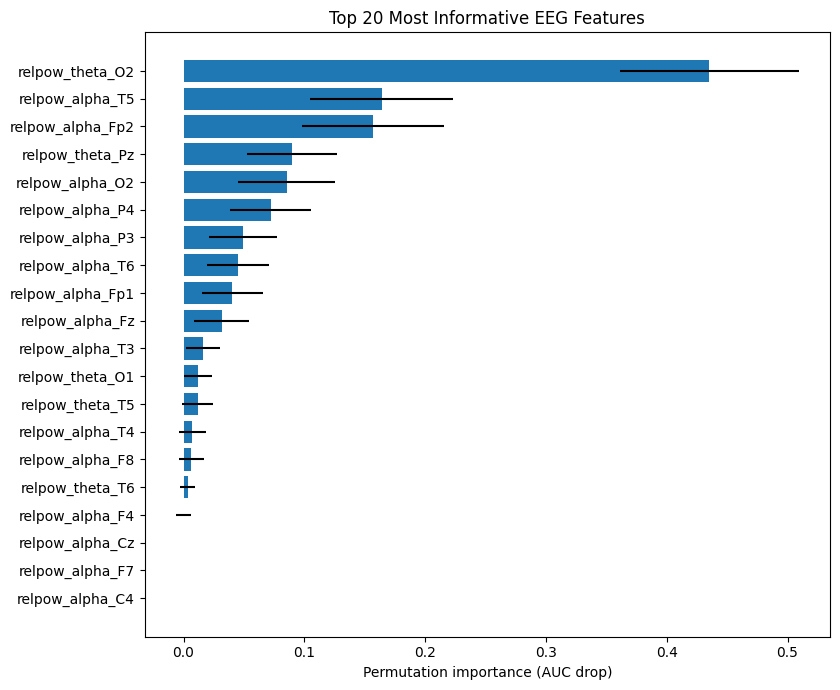

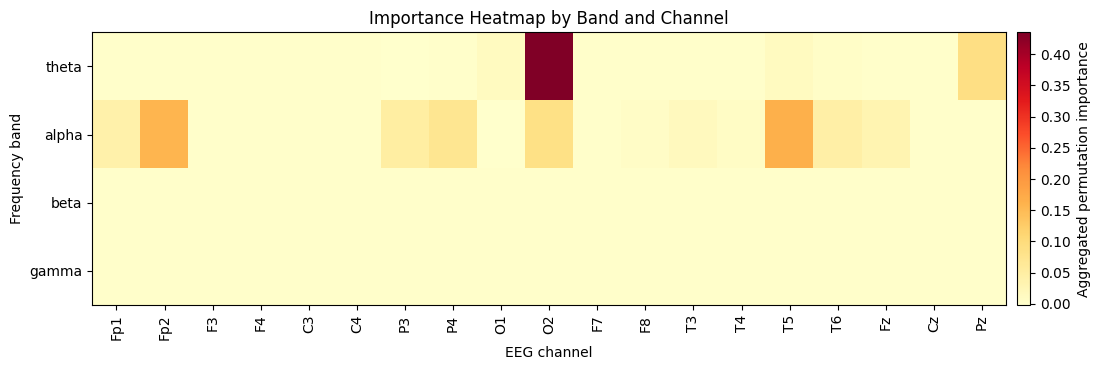

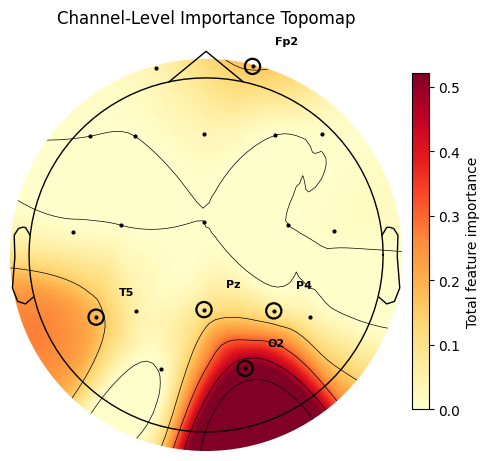

In [8]:
# Interpretability plots: top features, band-channel heatmap, channel topomap

top = imp_df.head(20).iloc[::-1]
fig, ax = plt.subplots(figsize=(8.5, 7.0))
ax.barh(top['feature'], top['importance_mean'], xerr=top['importance_std'], color='#1f77b4')
ax.set_xlabel('Permutation importance (AUC drop)')
ax.set_title('Top 20 Most Informative EEG Features')
plt.tight_layout()
plt.show()

rows = []
for _, row in imp_df.iterrows():
    parts = str(row['feature']).split('_')
    if len(parts) != 3:
        continue
    ftype, band, channel = parts
    rows.append({'feature_type': ftype, 'band': band, 'channel': channel, 'importance_mean': float(row['importance_mean'])})
parsed = pd.DataFrame(rows)

by_band_channel = parsed.groupby(['band', 'channel'], as_index=False)['importance_mean'].sum().pivot(
    index='band', columns='channel', values='importance_mean'
)
band_order = [b for b in BANDS.keys() if b in by_band_channel.index]
by_band_channel = by_band_channel.reindex(index=band_order, columns=common_channels).fillna(0.0)

fig, ax = plt.subplots(figsize=(12.0, 3.8))
im = ax.imshow(by_band_channel.values, aspect='auto', cmap='YlOrRd')
ax.set_yticks(np.arange(len(by_band_channel.index)))
ax.set_yticklabels(by_band_channel.index)
ax.set_xticks(np.arange(len(by_band_channel.columns)))
ax.set_xticklabels(by_band_channel.columns, rotation=90)
ax.set_title('Importance Heatmap by Band and Channel')
ax.set_xlabel('EEG channel')
ax.set_ylabel('Frequency band')
cbar = fig.colorbar(im, ax=ax, pad=0.01)
cbar.set_label('Aggregated permutation importance')
plt.tight_layout()
plt.show()

channel_imp = parsed.groupby('channel', as_index=False)['importance_mean'].sum().set_index('channel').reindex(common_channels).fillna(0.0)
vals = channel_imp['importance_mean'].values
top_channels = list(channel_imp['importance_mean'].sort_values(ascending=False).head(5).index)
mask = np.array([ch in top_channels for ch in common_channels], dtype=bool)
info = mne.create_info(ch_names=common_channels, sfreq=500.0, ch_types='eeg')
info.set_montage('standard_1020', on_missing='ignore')

fig, ax = plt.subplots(figsize=(5.2, 4.7))
vmax = max(np.max(vals), 1e-10)
im, _ = mne.viz.plot_topomap(
    vals, info, axes=ax, cmap='YlOrRd', vlim=(0, vmax), contours=6, show=False, sensors=False
)
xy = _find_topomap_coords(info, picks=np.arange(len(common_channels)))

# Draw all electrode dots
ax.scatter(xy[:, 0], xy[:, 1], s=9, c='black', linewidths=0, zorder=6)

# Draw circles around top channels
top_idx = [common_channels.index(ch) for ch in top_channels]
ax.scatter(
    xy[top_idx, 0],
    xy[top_idx, 1],
    s=120,
    facecolors='none',
    edgecolors='black',
    linewidths=1.6,
    zorder=7,
)


for ch in top_channels:
    idx = common_channels.index(ch)
    x, y0 = xy[idx]
    ax.text(x + 0.012, y0 + 0.012, ch, fontsize=8, weight='bold', zorder=8)

fig.colorbar(im, ax=ax, shrink=0.8, pad=0.02, label='Total feature importance')
ax.set_title('Channel-Level Importance Topomap')
plt.tight_layout()
plt.show()

In [9]:
# Clean summary output (bounded CIs from bootstrap)
metric_order = ['roc_auc', 'average_precision', 'balanced_accuracy', 'accuracy', 'f1', 'sensitivity', 'specificity', 'brier_score']
label_map = {
    'roc_auc': 'ROC-AUC',
    'average_precision': 'Avg Precision',
    'balanced_accuracy': 'Balanced Accuracy',
    'accuracy': 'Accuracy',
    'f1': 'F1',
    'sensitivity': 'Sensitivity (AD recall)',
    'specificity': 'Specificity (Control recall)',
    'brier_score': 'Brier Score (lower better)',
}

summary_rows = []
for m in metric_order:
    s = boot_summary[m]
    summary_rows.append({
        'Metric': label_map[m],
        'Mean': round(float(s['mean']), 3),
        '95% CI': f"[{s['ci95_low']:.3f}, {s['ci95_high']:.3f}]",
    })
summary_table = pd.DataFrame(summary_rows)

model_table = pd.DataFrame([
    {'Selected model': k, 'Count': int(v)}
    for k, v in summary['selected_model_counts'].items()
]).sort_values('Count', ascending=False)

report_df = pd.DataFrame(
    classification_report(
        y_true_oof,
        y_pred_oof,
        target_names=['Control (C)', "Alzheimer's (A)"],
        output_dict=True,
        zero_division=0,
    )
).T
for col in ['precision', 'recall', 'f1-score']:
    if col in report_df.columns:
        report_df[col] = report_df[col].astype(float).round(3)
if 'support' in report_df.columns:
    report_df['support'] = report_df['support'].astype(float).round(0).astype(int)

print('Performance Summary (OOF)')
display(summary_table)

print('Model Selection Stability')
display(model_table)

print(f"Permutation AUC test p-value: {perm_test['permutation_p_value']:.4g}")
print('Classification Report (OOF)')
display(report_df)

Performance Summary (OOF)


,Metric,Mean,95% CI
0,ROC-AUC,0.800,"[0.676, 0.907]"
1,Avg Precision,0.821,"[0.689, 0.930]"
2,Balanced Accuracy,0.750,"[0.637, 0.848]"
3,Accuracy,0.753,"[0.646, 0.846]"
4,F1,0.777,"[0.676, 0.868]"
5,Sensitivity (AD recall),0.777,"[0.639, 0.890]"
6,Specificity (Control recall),0.723,"[0.552, 0.862]"
7,Brier Score (lower better),0.180,"[0.115, 0.256]"


Model Selection Stability


,Selected model,Count
0,logreg_select,5


Permutation AUC test p-value: 0.000999
Classification Report (OOF)


,precision,recall,f1-score,support
Control (C),0.778,0.724,0.750,29
Alzheimer's (A),0.789,0.833,0.811,36
accuracy,0.785,0.785,0.785,1
macro avg,0.784,0.779,0.780,65
weighted avg,0.784,0.785,0.784,65


In [ ]:
# Gradient Boosting Comparison (Optional)
# Compares current baseline (logreg_select) vs XGBoost/LightGBM using the same nested CV logic.

from sklearn.metrics import accuracy_score, roc_auc_score, balanced_accuracy_score, f1_score


def _benchmark_models_nested_cv(X, y):
    outer_cv = StratifiedKFold(n_splits=OUTER_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    inner_cv = StratifiedKFold(n_splits=INNER_FOLDS, shuffle=True, random_state=RANDOM_STATE)

    model_dict = {
        'logreg_select': (
            Pipeline([
                ('scaler', StandardScaler()),
                ('sel', SelectKBest(f_classif)),
                ('clf', LogisticRegression(solver='liblinear', random_state=RANDOM_STATE, max_iter=5000)),
            ]),
            {
                'sel__k': [40, 80, 120] if RUNTIME_PROFILE == 'fast' else [20, 40, 60, 80, 120],
                'clf__C': [0.1, 1.0, 10.0] if RUNTIME_PROFILE == 'fast' else [0.01, 0.1, 1.0, 10.0, 100.0],
                'clf__class_weight': [None, 'balanced'],
            },
        )
    }

    if XGBClassifier is not None:
        model_dict['xgboost'] = (
            Pipeline([
                ('sel', SelectKBest(f_classif)),
                ('clf', XGBClassifier(
                    objective='binary:logistic',
                    eval_metric='logloss',
                    random_state=RANDOM_STATE,
                    n_estimators=600,
                    n_jobs=1,
                    tree_method='hist',
                )),
            ]),
            {
                'sel__k': [40, 80, 120] if RUNTIME_PROFILE == 'fast' else [20, 40, 60, 80, 120],
                'clf__max_depth': [3, 5],
                'clf__learning_rate': [0.03, 0.1],
                'clf__subsample': [0.8, 1.0],
                'clf__colsample_bytree': [0.8, 1.0],
            },
        )

    if LGBMClassifier is not None:
        model_dict['lightgbm'] = (
            Pipeline([
                ('sel', SelectKBest(f_classif)),
                ('clf', LGBMClassifier(
                    objective='binary',
                    random_state=RANDOM_STATE,
                    n_estimators=600,
                    n_jobs=1,
                    verbosity=-1,
                )),
            ]),
            {
                'sel__k': [40, 80, 120] if RUNTIME_PROFILE == 'fast' else [20, 40, 60, 80, 120],
                'clf__num_leaves': [15, 31],
                'clf__learning_rate': [0.03, 0.1],
                'clf__subsample': [0.8, 1.0],
                'clf__colsample_bytree': [0.8, 1.0],
            },
        )

    rows = []
    for model_name, (pipe, grid) in model_dict.items():
        fold_metrics = []
        for tr_idx, te_idx in outer_cv.split(X, y):
            X_tr, X_te = X[tr_idx], X[te_idx]
            y_tr, y_te = y[tr_idx], y[te_idx]

            gs = GridSearchCV(clone(pipe), grid, scoring='roc_auc', cv=inner_cv, n_jobs=N_JOBS, refit=True)
            gs.fit(X_tr, y_tr)

            # same threshold policy as notebook
            train_prob = gs.best_estimator_.predict_proba(X_tr)[:, 1]
            threshold = _best_train_threshold(y_tr, train_prob)

            prob = gs.best_estimator_.predict_proba(X_te)[:, 1]
            pred = (prob >= threshold).astype(int)

            fold_metrics.append({
                'accuracy': accuracy_score(y_te, pred),
                'balanced_accuracy': balanced_accuracy_score(y_te, pred),
                'roc_auc': roc_auc_score(y_te, prob),
                'f1': f1_score(y_te, pred),
            })

        dfm = pd.DataFrame(fold_metrics)
        rows.append({
            'model': model_name,
            'accuracy_mean': float(dfm['accuracy'].mean()),
            'balanced_accuracy_mean': float(dfm['balanced_accuracy'].mean()),
            'roc_auc_mean': float(dfm['roc_auc'].mean()),
            'f1_mean': float(dfm['f1'].mean()),
        })

    out = pd.DataFrame(rows).sort_values(['accuracy_mean', 'roc_auc_mean'], ascending=False)
    return out

comparison_df = _benchmark_models_nested_cv(X, y)
comparison_df[['accuracy_mean','balanced_accuracy_mean','roc_auc_mean','f1_mean']] = comparison_df[['accuracy_mean','balanced_accuracy_mean','roc_auc_mean','f1_mean']].round(3)
print('Model comparison with same nested CV protocol:')
display(comparison_df)


In [ ]:
# confusion-matrix-only export
fig, ax = plt.subplots(figsize=(4.8, 4.3), constrained_layout=True)
ConfusionMatrixDisplay.from_predictions(
    y_true_oof,
    y_pred_oof,
    display_labels=['Control (C)', "Alzheimer's (A)"],
    cmap='Blues',
    ax=ax,
    colorbar=False,
)
ax.set_title('Confusion Matrix (OOF)')
fig.savefig('classification_confusion_matrix_only.png', dpi=600, bbox_inches='tight')
plt.show()
print('Saved classification_confusion_matrix_only.png')